In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.observables.cmb import CMBLensingTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** interface.

In [2]:
# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.,
                            gamma_MG = 0.545,
                            N_mnu = 0)

# We need to compute perturbations up to~z_* in order to compute the CMB lensing power spectrum
z_camb = np.logspace(-3,np.log10(1100),256)
linear_perturbations_camb = CAMBLinearPerturbations(background, redshifts=z_camb)
nonlinear_perturbations_camb = CAMBNonLinearPerturbations(background, linear_perturbations_camb, redshifts=z_camb)

# We choose to use the non-linear perturbations from camb
perturbations = nonlinear_perturbations_camb

# We also define two redshift vectors that will be used when integrating over the line of sight
# For the cross-correlations we only need to integrate low redshifts
# For the cmb lensing auto-power spectrum, we need to integrate up to z_*
z_cross = np.linspace(1e-3, 3, 200)
z_auto = np.arange(1e-3,perturbations.background.z_star,0.01)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [3]:
# Execute this cell to download the data
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

nz_example.fits downloaded successfully
mixmats_example.fits downloaded successfully
cls_example.fits downloaded successfully


In [4]:
# Read the data using euclidlib v2025.w
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.phz.redshift_distributions('nz_example.fits')
mixmats_example = el.le3.pk_wl.mixing_matrices('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

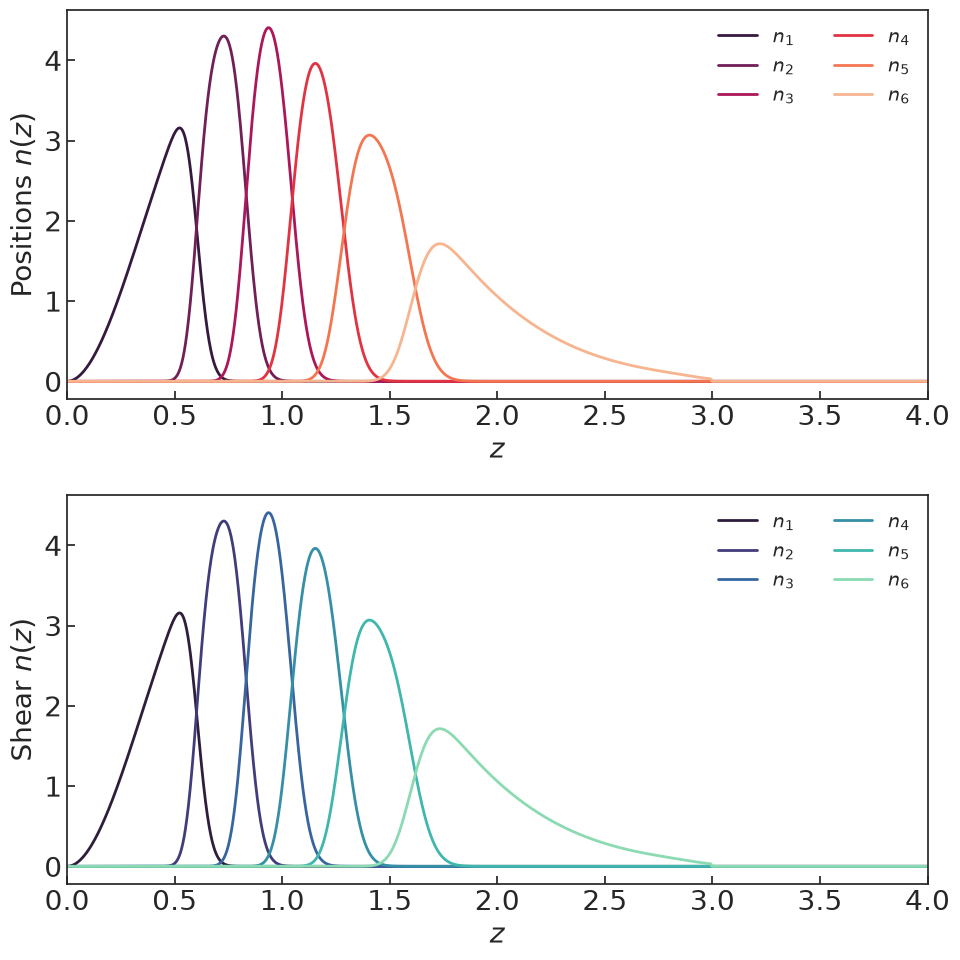

In [5]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, z_cross)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, z_cross)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## Observables: shear, position and cmb lensing tracers 

We compute tracers (window functions) for shear, galaxy positions and cmb lensing observations, to be later combined in the computation of the summary statistics.

In [6]:
# Define the tracers
tracer_pos = PositionsTracer(perturbations=perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = z_cross,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                                              'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                                              'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                                              'width_pos_1': 1.0, 'width_pos_2': 1.0,
                                              'width_pos_3': 1.0, 'width_pos_4': 1.0,
                                              'width_pos_5': 1.0, 'width_pos_6': 1.0})

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = z_cross,
                             nuisance_params={'AIA': 0., 'CIA': 0., 'EtaIA': 0.,
                                              'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                                              'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                                              'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                                              'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                                              'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                                              'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
                                              'width_shear_1': 1.0, 'width_shear_2': 1.0,
                                              'width_shear_3': 1.0, 'width_shear_4': 1.0,
                                              'width_shear_5': 1.0, 'width_shear_6': 1.0})


tracer_cmblens_cross = CMBLensingTracer(perturbations=perturbations, z=z_cross)
tracer_cmblens_auto = CMBLensingTracer(perturbations=perturbations, z=z_auto)

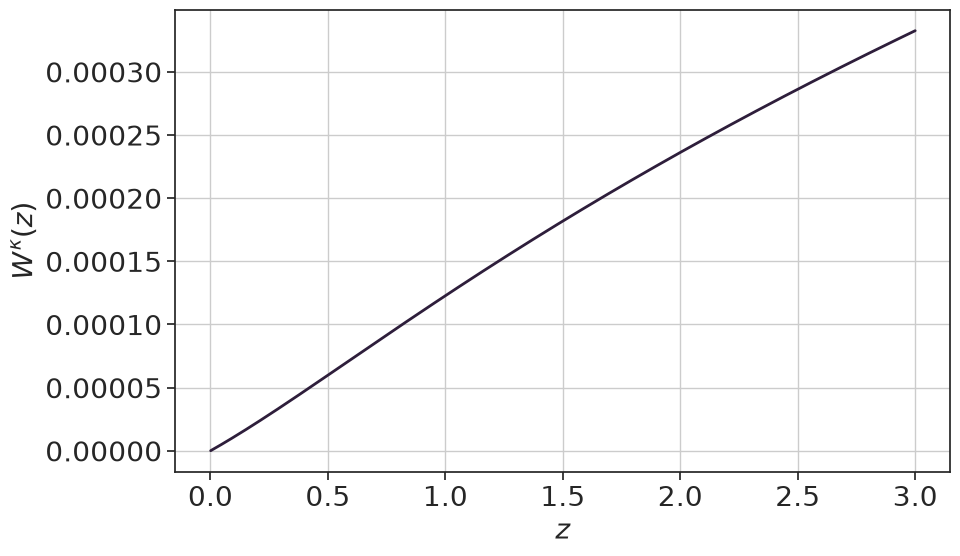

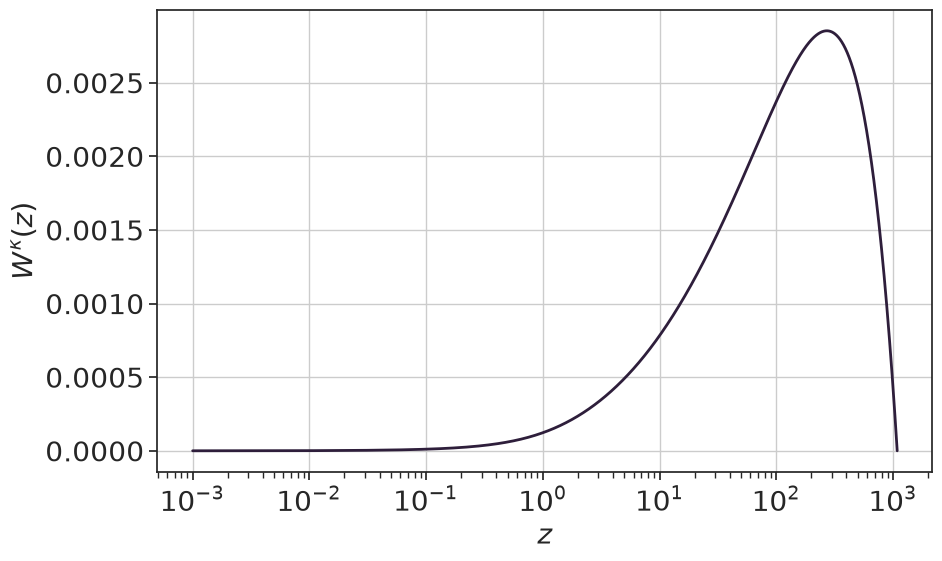

In [7]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Plot the cmb lensing window function on z_cross
plt.figure(figsize=(10, 6))
plt.plot(z_cross,
         tracer_cmblens_cross.get_window(z_cross)[0],
         linewidth=2, 
         color=colors[0])
plt.xlabel(r'$z$')
plt.ylabel(r'$W^\kappa(z)$')
plt.grid(True)
plt.show()

# Plot the cmb lensing window function on z_auto
plt.figure(figsize=(10, 6))
plt.plot(z_auto,
         tracer_cmblens_auto.get_window(z_auto)[0],
         linewidth=2, 
         color=colors[0])
plt.semilogx()
plt.xlabel(r'$z$')
plt.ylabel(r'$W^\kappa(z)$')
plt.grid(True)
plt.show()

## Two-point statistics

### Theoretical Predictions: $C_\ell$

We compute angular power spectra initialising the corresponding `cloelib` class.

In [8]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_kpos = AngularTwoPoint(tracer_cmblens_cross, tracer_pos)
twopoint_kshe = AngularTwoPoint(tracer_cmblens_cross, tracer_she)
twopoint_kk = AngularTwoPoint(tracer_cmblens_auto, tracer_cmblens_auto)

cells ={**twopoint_kpos.get_Cl(ells, 0, perturbations.k)
, **twopoint_kshe.get_Cl(ells, 0, perturbations.k)
, **twopoint_kk.get_Cl(ells, 0, perturbations.k)}

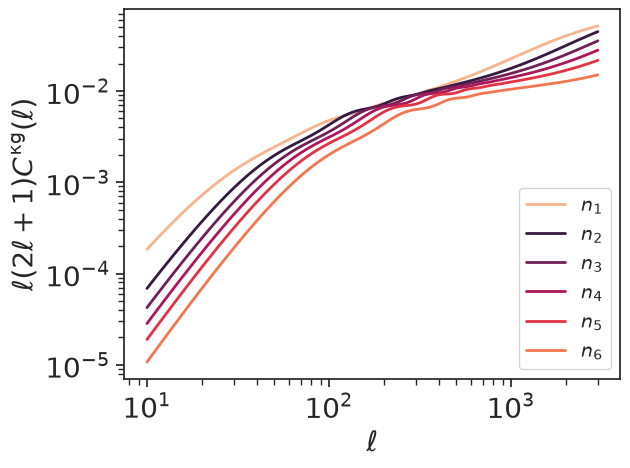

In [9]:
plt.figure()
for i in range(6):
    ells = cells['CMBL', 'POS', 1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['CMBL', 'POS', 1, i+1], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm \kappa g}(\ell)$');
plt.legend(fontsize=14);

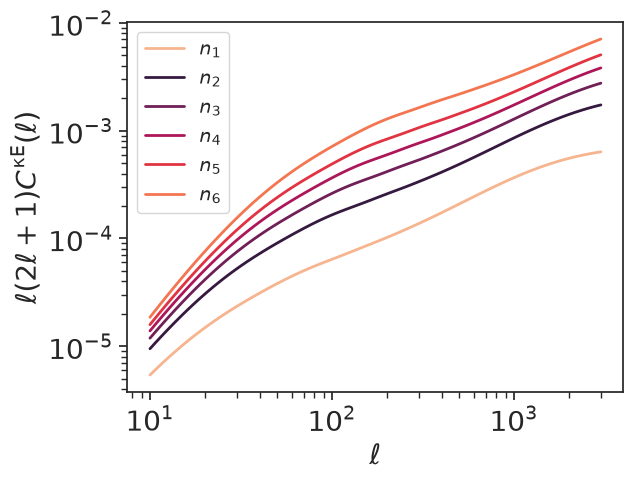

In [10]:
plt.figure()
for i in range(6):
    ells = cells['CMBL', 'SHE', 1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['CMBL', 'SHE', 1, i+1][0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm \kappa E}(\ell)$');
plt.legend(fontsize=14);

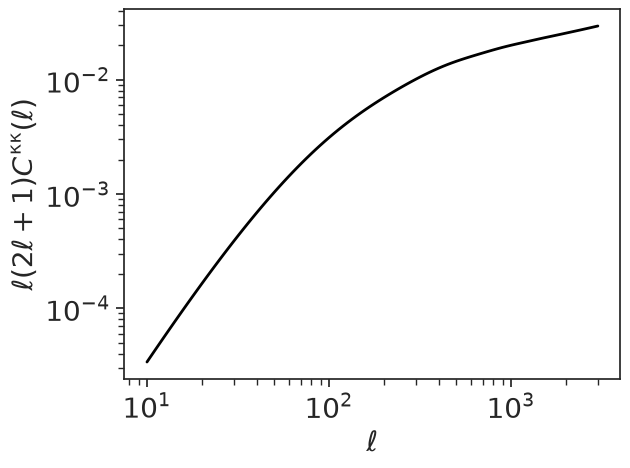

In [11]:
plt.figure()
ells = cells['CMBL', 'CMBL', 1, 1].ell
plt.loglog(ells, ells*(2*ells+1)*cells['CMBL', 'CMBL', 1, 1], linewidth=2, c='black')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm \kappa \kappa}(\ell)$');

## Benchmark against CAMB (auto-power spectrum)

In [12]:
import camb
from camb import model

# We can use the CAMBparams object of perturbations.background,
# but have to update some parameters to compute the cmb lensing power spectrum
perturbations.background.interface_args["CAMBparams"].WantCls = True
perturbations.background.interface_args["CAMBparams"].DoLensing = True
perturbations.background.interface_args["CAMBparams"].Want_CMB = True
perturbations.background.interface_args["CAMBparams"].Want_CMB_lensing = True
perturbations.background.interface_args["CAMBparams"].max_l = 3000
perturbations.background.interface_args["CAMBparams"].NonLinear = model.NonLinear_both

# Also increase lens_potential_accuracy to get accurate results at small scales
perturbations.background.interface_args["CAMBparams"].set_for_lmax(lmax=3000, lens_potential_accuracy=4)

# Compute the power spectra
results = camb.get_results(perturbations.background.interface_args["CAMBparams"])
cl_kk_camb = results.get_lens_potential_cls()[:,0]*np.pi/2
ells_camb = np.arange(0,len(cl_kk_camb),1)

# Interpolate to get camb's power spectrum at the same ells as cloe
cl_kk_camb = np.interp(ells, ells_camb, cl_kk_camb)

/leonardo/home/userexternal/rkou0000/miniconda3/envs/cloe-org-env/lib/python3.12/site-packages/matplotlib/scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


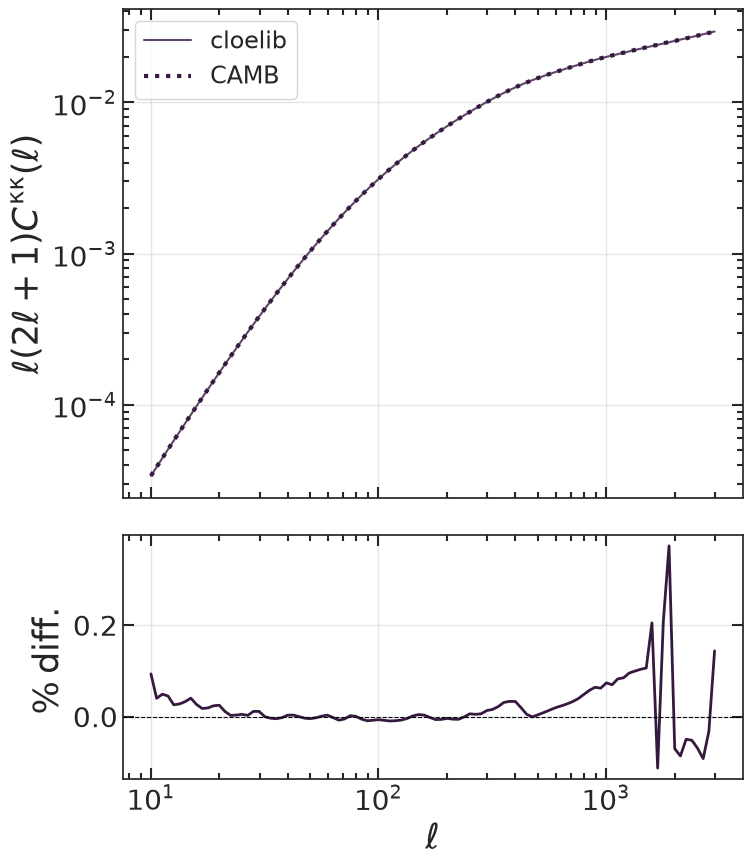

In [13]:
# Compare CAMB/cloe CMB lensing power spectra
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm \kappa\kappa}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')


axs[0].loglog(ells, ells*(2*ells+1)*cells['CMBL', 'CMBL', 1, 1], color=sns.color_palette("rocket", 6)[0], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
axs[0].loglog(ells, ells*(2*ells+1)*cl_kk_camb, color=sns.color_palette("rocket", 6)[0], ls=':', linewidth=3, label = r'$\rm{CAMB}$')
axs[1].plot(ells, (cl_kk_camb - cells['CMBL', 'CMBL', 1, 1])/cl_kk_camb*100, linewidth=2, color=sns.color_palette("rocket", 6)[0])

#axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


## Benchmark against CCL

In [14]:
#If pyccl is installed...
import pyccl as ccl

cosmo = ccl.Cosmology(h = background.h,
                      Omega_c = background.Omega_cdm0,
                      Omega_b = background.Omega_b0,
                      m_nu = background.mnu,
                      Neff = background.N_eff,
                      w0 = background.w0,
                      wa = background.wa,
                      Omega_k = background.Omega_k0,
                      n_s = background.ns,
                      A_s = background.As,
                      matter_power_spectrum = 'camb',
                      extra_parameters = {'camb':{"halofit_version": perturbations.background.interface_args["CAMBparams"].NonLinearModel.halofit_version}},
                      transfer_function='boltzmann_camb',
                      T_ncdm=0
                      )

In [15]:
bias_array = np.ones(len(z_cross))                                 
tracer_pos_ccl = {}
tracer_pos_ccl_norm = {}
tracer_she_ccl = {}
tracer_she_ccl_norm = {}
for i in range(6):
    tracer_pos_ccl[str(i)] = ccl.NumberCountsTracer(cosmo,
                                                    has_rsd=False,
                                                    dndz=(z_cross, my_dndz_pos_norm[i]),
                                                    bias=(z_cross, bias_array))
    


    tracer_she_ccl[str(i)] = ccl.WeakLensingTracer(cosmo,
                                                   dndz=(z_cross, my_dndz_she_norm[i]),
                                                   ia_bias=None, use_A_ia=False)

tracer_cmbl_ccl = ccl.CMBLensingTracer(cosmo,
                                       z_source=perturbations.background.z_star)

In [16]:
# CCL Power spectra
cells_kg_ccl={}
cells_kE_ccl={}
cells_kk_ccl={}
for i in range(6):
    cells_kg_ccl[str(i)] = ccl.angular_cl(cosmo, tracer_cmbl_ccl, tracer_pos_ccl[str(i)], ells)
    cells_kE_ccl[str(i)] = ccl.angular_cl(cosmo, tracer_cmbl_ccl, tracer_she_ccl[str(i)], ells) 
cells_kk_ccl["0"] = ccl.angular_cl(cosmo, tracer_cmbl_ccl, tracer_cmbl_ccl, ells) 

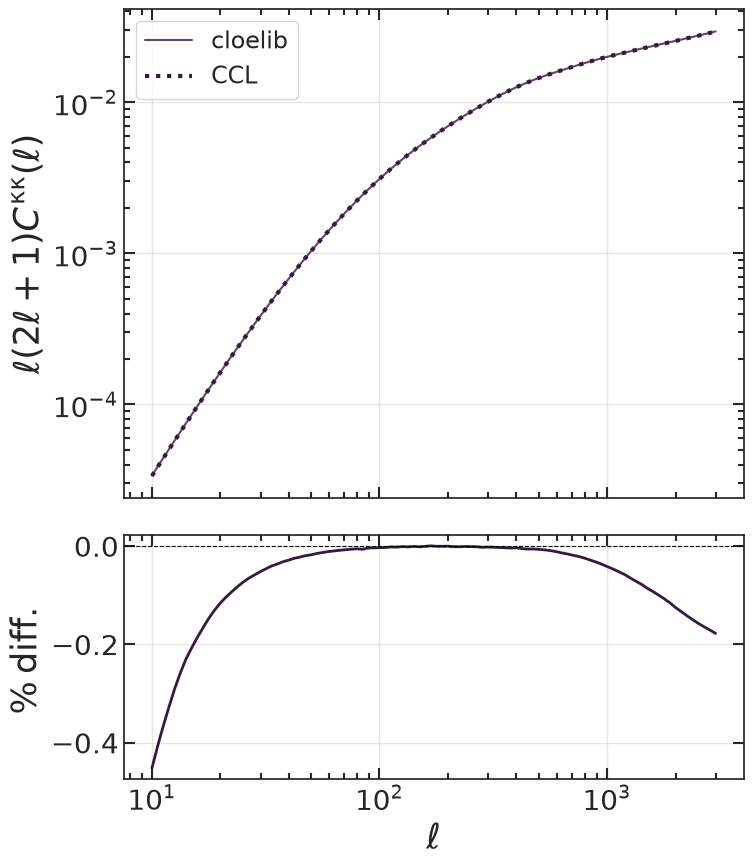

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm \kappa\kappa}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')


axs[0].loglog(ells, ells*(2*ells+1)*cells['CMBL', 'CMBL', 1, 1], color=sns.color_palette("rocket", 6)[0], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
axs[0].loglog(ells, ells*(2*ells+1)*cells_kk_ccl['0'], color=sns.color_palette("rocket", 6)[0], ls=':', linewidth=3, label = r'$\rm{CCL}$')
axs[1].plot(ells, (cells_kk_ccl['0'] - cells['CMBL', 'CMBL', 1, 1])/cells_kk_ccl['0']*100, linewidth=2, color=sns.color_palette("rocket", 6)[0])

#axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


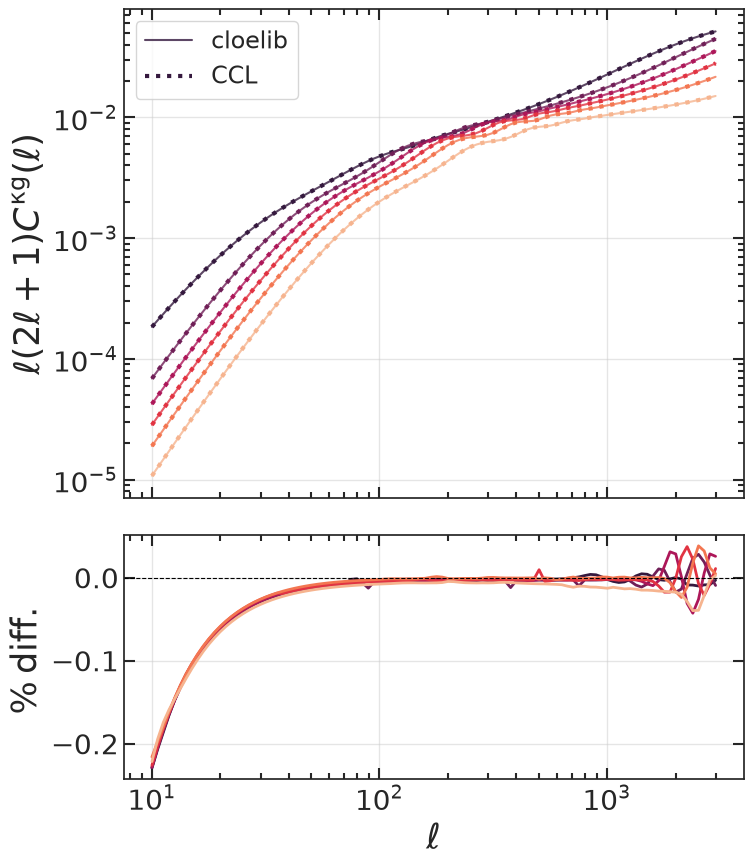

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm \kappa g}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==0:
        axs[0].loglog(ells, ells*(2*ells+1)*cells['CMBL', 'POS', 1, i+1], color=sns.color_palette("rocket", 6)[i], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_kg_ccl[str(i)], color=sns.color_palette("rocket", 6)[i], ls=':', linewidth=3, label = r'$\rm{CCL}$')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells['CMBL', 'POS', 1, i+1], linewidth=1.5, alpha=0.8, color=sns.color_palette("rocket", 6)[i])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_kg_ccl[str(i)], ls=':', linewidth=3, color=sns.color_palette("rocket", 6)[i])

    axs[1].plot(ells, (cells_kg_ccl[str(i)] - cells['CMBL', 'POS', 1, i+1])/cells_kg_ccl[str(i)]*100, linewidth=2, color=sns.color_palette("rocket", 6)[i])

#axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


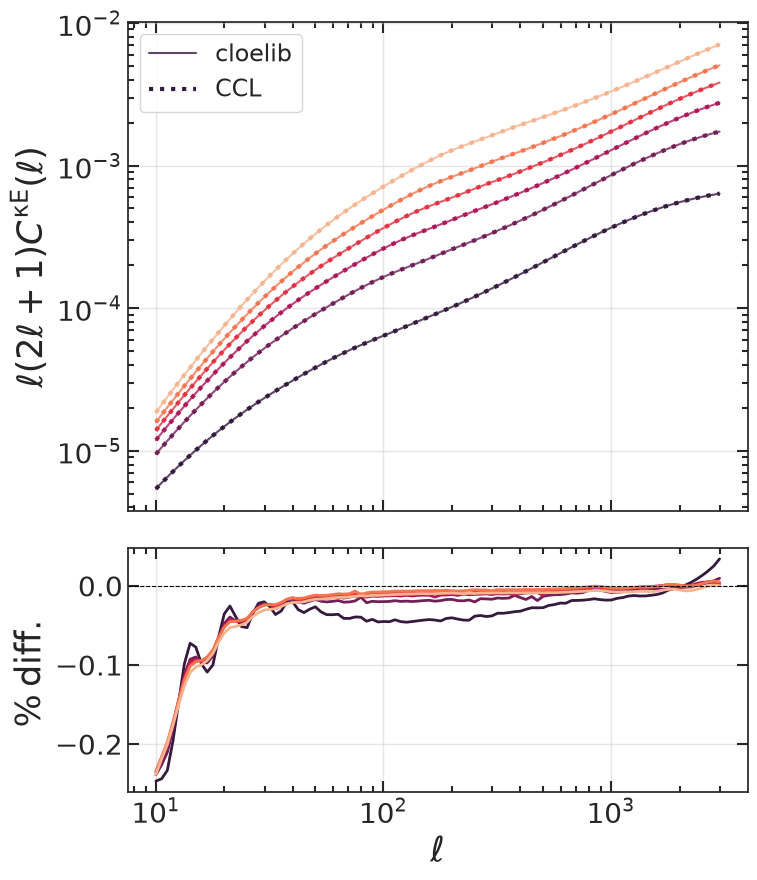

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm \kappa E}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==0:
        axs[0].loglog(ells, ells*(2*ells+1)*cells['CMBL', 'SHE', 1, i+1][0], color=sns.color_palette("rocket", 6)[i], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_kE_ccl[str(i)], color=sns.color_palette("rocket", 6)[i], ls=':', linewidth=3, label = r'$\rm{CCL}$')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells['CMBL', 'SHE', 1, i+1][0], linewidth=1.5, alpha=0.8, color=sns.color_palette("rocket", 6)[i])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_kE_ccl[str(i)], ls=':', linewidth=3, color=sns.color_palette("rocket", 6)[i])

    axs[1].plot(ells, (cells_kE_ccl[str(i)] - cells['CMBL', 'SHE', 1, i+1][0])/cells_kE_ccl[str(i)]*100, linewidth=2, color=sns.color_palette("rocket", 6)[i])

#axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)
